This notebook filters drifters velocities by

1. Applying a 2nd order low-pass Butterworth filter on the drifters velocities,
2. Removing the Ekman component estimated using the empirical model of Rio et al. (2014) and ERA5 wind stress data,
3. Re-applying the same 2nd order low-pass Butterworth filter on the Ekman-free drifters velocities.

The appropriate cutoff period for the Butterworth filter was choosen by looking at the rotary spectrum.

The coefficients of the empirical Ekman model are estimated for the Med Sea using DUACS geostrophic velocities, following the methodology employed in Rio et al. (2014).

In [1]:
import clouddrift as cd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt
import xarray as xr

In [2]:
drifter_ds = xr.open_zarr("data/drifters_drogue15m_CalVal.zarr").compute()

## 1. Low-pass Butterworth Filter

In [3]:
def get_butter_lowpass(dt=1, cutoff=48, order=2):
    dt_sec = dt * 3600
    cutoff_sec = cutoff * 3600

    nyq_hz = 0.5 / dt_sec
    cutoff_hz = 1.0 / cutoff_sec
    normal_cutoff = cutoff_hz / nyq_hz

    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return b, a


def apply_butter_lowpass(u, v, b, a):
    uv = u + 1j * v

    filtered = filtfilt(b, a, uv)

    return filtered.real, filtered.imag


def remove_high_freq(ds, filtered=False, dt=1, cutoff=48, order=2):
    _, indexes, counts = np.unique(ds.drifter_id, return_index=True, return_counts=True)
    rowsize = counts[np.argsort(indexes)]

    if filtered:
        u = ds["velocity_east_filtered"].values
        v = ds["velocity_north_filtered"].values
    else:
        u = ds["velocity_east"].values
        v = ds["velocity_north"].values

    b, a = get_butter_lowpass(dt=dt, cutoff=cutoff, order=order)

    filtered_u, filtered_v = cd.ragged.apply_ragged(apply_butter_lowpass, (u, v), rowsize=rowsize, b=b, a=a)

    ds["velocity_east_filtered"] = ("points", filtered_u)
    ds["velocity_north_filtered"] = ("points", filtered_v)

    return ds

In [4]:
cutoff = 20  # hours

drifter_ds = remove_high_freq(drifter_ds, cutoff=cutoff)
drifter_ds = remove_high_freq(drifter_ds, filtered=True, cutoff=cutoff)
drifter_ds = remove_high_freq(drifter_ds, filtered=True, cutoff=cutoff)
drifter_ds = remove_high_freq(drifter_ds, filtered=True, cutoff=cutoff)

### PSD

In [5]:
def welch_rotary(z, dt=1, nperseg=128, noverlap=None):
    if not np.iscomplexobj(z):
        raise ValueError("Input must be complex (u + 1j*v)")

    dt_sec = dt * 3600
    N = len(z)

    if noverlap is None:
        noverlap = nperseg // 2

    step = nperseg - noverlap

    window = np.hanning(nperseg)
    U = np.sum(window**2)

    freqs = np.fft.fftfreq(nperseg, dt_sec)
    pos = freqs > 0
    neg = freqs < 0

    f_ccw = freqs[pos]
    f_cw  = -freqs[neg]

    Sccw_list = []
    Scw_list  = []

    n_segments = (N - nperseg) // step + 1
    for i in range(max(n_segments, 0)):
        start = i * step
        seg = z[start:start + nperseg]
        if not np.all(np.isfinite(seg)):
            continue
        seg = (seg - np.mean(seg)) * window
        Z = np.fft.fft(seg)
        S = np.abs(Z)**2 / (U * dt_sec)
        Sccw_list.append(S[pos])
        Scw_list.append(S[neg])

    if not Sccw_list:
        return f_ccw, np.full_like(f_ccw, np.nan), f_cw, np.full_like(f_cw, np.nan)

    return f_ccw, np.mean(Sccw_list, axis=0), f_cw, np.mean(Scw_list, axis=0)

In [6]:
_, indexes, counts = np.unique(drifter_ds.drifter_id, return_index=True, return_counts=True)
rowsize = counts[np.argsort(indexes)]

In [7]:
# Complex velocities
z = drifter_ds.velocity_east + 1j * drifter_ds.velocity_north
z_fitered = drifter_ds.velocity_east_filtered + 1j * drifter_ds.velocity_north_filtered

n_perseg = 128 * 8

f_ccw, Sccw, f_cw, Scw = cd.ragged.apply_ragged(welch_rotary, z, rowsize=rowsize, nperseg=n_perseg)
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = cd.ragged.apply_ragged(
    welch_rotary, z_fitered, rowsize=rowsize, nperseg=n_perseg
)

f_ccw, Sccw, f_cw, Scw = map(lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw, Sccw, f_cw, Scw))
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = map(
    lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered)
)

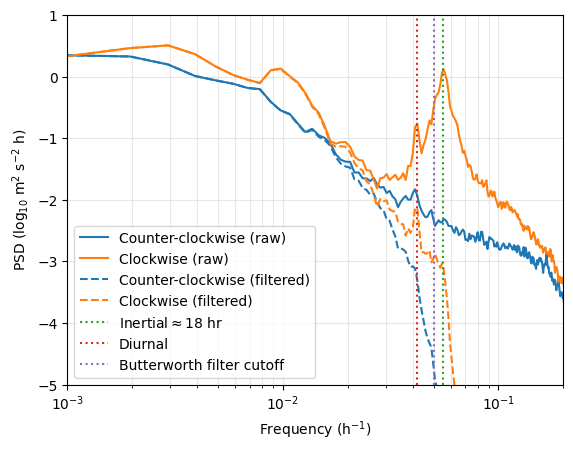

In [8]:
plt.figure()

f_ccw_h = f_ccw * 3600
f_cw_h  = f_cw  * 3600

Sccw_h = Sccw * 3600
Scw_h  = Scw  * 3600
Sccw_fitered_h = Sccw_fitered * 3600
Scw_fitered_h  = Scw_fitered  * 3600

plt.semilogx(f_ccw_h, np.log10(Sccw_h), label="Counter-clockwise (raw)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_h), label="Clockwise (raw)", color="C1")
plt.semilogx(f_ccw_h, np.log10(Sccw_fitered_h), "--", label="Counter-clockwise (filtered)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_fitered_h), "--", label="Clockwise (filtered)", color="C1")

plt.axvline(1/18, color="C2", linestyle=":", label="Inertial$\\approx 18$ hr")
plt.axvline(1/24, color="C3", linestyle=":", label="Diurnal")
plt.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth filter cutoff")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(1e-3, 2e-1)
plt.ylim(-5, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

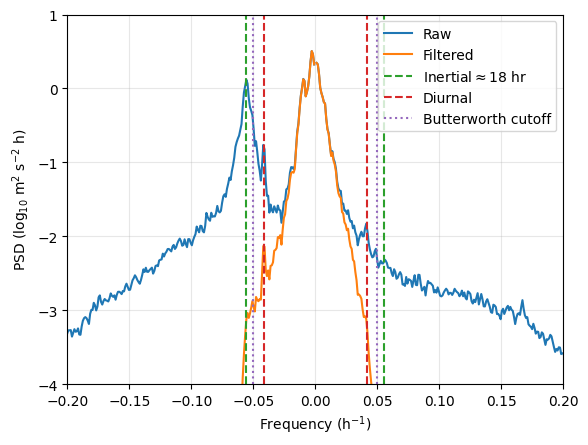

In [9]:
fig, ax = plt.subplots()

ax.plot(-f_cw_h, np.log10(Scw_h), color="C0", label="Raw")
ax.plot(f_ccw_h, np.log10(Sccw_h), color="C0")
ax.plot(-f_cw_h, np.log10(Scw_fitered_h), color="C1", label="Filtered")
ax.plot(f_ccw_h, np.log10(Sccw_fitered_h), color="C1",)

ax.axvline(-1/18, color="C2", linestyle="--", label="Inertial$\\approx 18$ hr")
ax.axvline(1/18, color="C2", linestyle="--")
ax.axvline(-1/24, color="C3", linestyle="--", label="Diurnal")
ax.axvline(1/24, color="C3", linestyle="--")
ax.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth cutoff")
ax.axvline(-1/cutoff, color="C4", linestyle=":")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(-2e-1, 2e-1)
plt.ylim(-4, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

## 2. Remove Ekman contribution

### 2.1. Fit the parameters of the empirical Ekman model

In [10]:
eastward_velocity = drifter_ds["velocity_east_filtered"].values
northward_velocity = drifter_ds["velocity_north_filtered"].values

ugos = drifter_ds["ugos"].values
vgos = drifter_ds["vgos"].values
eastward_stress = drifter_ds["eastward_stress"].values
northward_stress = drifter_ds["northward_stress"].values

In [11]:
v_d = eastward_velocity + 1j * northward_velocity
u_g = ugos + 1j * vgos
tau = eastward_stress + 1j * northward_stress

residual = v_d - u_g

In [12]:
valid = np.isfinite(residual) & np.isfinite(tau)
res, t = residual[valid], tau[valid]

In [13]:
np.sum(valid), np.sum(~valid)

(np.int64(80722), np.int64(3999))

In [14]:
alpha = np.dot(t.conj(), res) / np.dot(t.conj(), t)

beta  = np.abs(alpha)
theta = np.angle(alpha)  # radians

In [15]:
print(f"beta  = {beta:.4f}")
print(f"theta = {np.degrees(theta):.2f}°")

beta  = 0.3066
theta = -75.84°


### 2.2. Remove the contribution estimated from the fitted model

In [16]:
def remove_ekman(ds):
    eastward_velocity = ds["velocity_east_filtered"].values
    northward_velocity = ds["velocity_north_filtered"].values

    eastward_stress = ds["eastward_stress"].values
    northward_stress = ds["northward_stress"].values

    v_d = eastward_velocity + 1j * northward_velocity
    tau = eastward_stress + 1j * northward_stress

    v_d_filtered = v_d - alpha * tau

    ds["velocity_east_filtered"] = ("points", v_d_filtered.real)
    ds["velocity_north_filtered"] = ("points", v_d_filtered.imag)

    return ds

In [17]:
drifter_ds = remove_ekman(drifter_ds)

### PSD

In [18]:
# Complex velocities
z = drifter_ds.velocity_east + 1j * drifter_ds.velocity_north
z_fitered = drifter_ds.velocity_east_filtered + 1j * drifter_ds.velocity_north_filtered

n_perseg = 128 * 8

f_ccw, Sccw, f_cw, Scw = cd.ragged.apply_ragged(welch_rotary, z, rowsize=rowsize, nperseg=n_perseg)
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = cd.ragged.apply_ragged(
    welch_rotary, z_fitered, rowsize=rowsize, nperseg=n_perseg
)

f_ccw, Sccw, f_cw, Scw = map(lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw, Sccw, f_cw, Scw))
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = map(
    lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered)
)

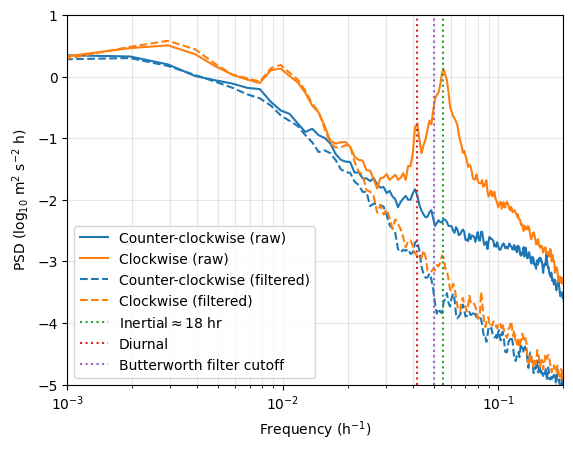

In [19]:
plt.figure()

f_ccw_h = f_ccw * 3600
f_cw_h  = f_cw  * 3600

Sccw_h = Sccw * 3600
Scw_h  = Scw  * 3600
Sccw_fitered_h = Sccw_fitered * 3600
Scw_fitered_h  = Scw_fitered  * 3600

plt.semilogx(f_ccw_h, np.log10(Sccw_h), label="Counter-clockwise (raw)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_h), label="Clockwise (raw)", color="C1")
plt.semilogx(f_ccw_h, np.log10(Sccw_fitered_h), "--", label="Counter-clockwise (filtered)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_fitered_h), "--", label="Clockwise (filtered)", color="C1")

plt.axvline(1/18, color="C2", linestyle=":", label="Inertial$\\approx 18$ hr")
plt.axvline(1/24, color="C3", linestyle=":", label="Diurnal")
plt.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth filter cutoff")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(1e-3, 2e-1)
plt.ylim(-5, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

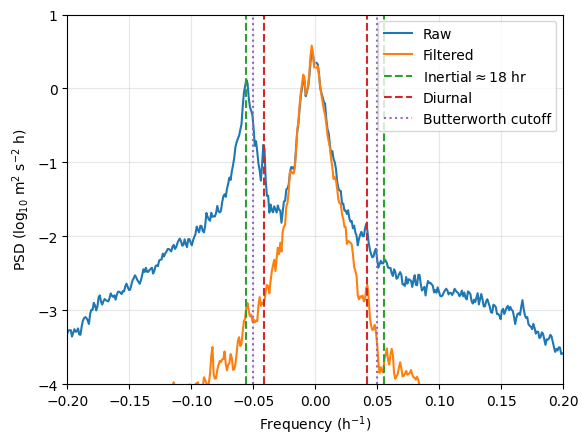

In [20]:
fig, ax = plt.subplots()

ax.plot(-f_cw_h, np.log10(Scw_h), color="C0", label="Raw")
ax.plot(f_ccw_h, np.log10(Sccw_h), color="C0")
ax.plot(-f_cw_h, np.log10(Scw_fitered_h), color="C1", label="Filtered")
ax.plot(f_ccw_h, np.log10(Sccw_fitered_h), color="C1",)

ax.axvline(-1/18, color="C2", linestyle="--", label="Inertial$\\approx 18$ hr")
ax.axvline(1/18, color="C2", linestyle="--")
ax.axvline(-1/24, color="C3", linestyle="--", label="Diurnal")
ax.axvline(1/24, color="C3", linestyle="--")
ax.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth cutoff")
ax.axvline(-1/cutoff, color="C4", linestyle=":")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(-2e-1, 2e-1)
plt.ylim(-4, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

## 3. Re-apply the low-pass filter

In [21]:
drifter_ds = remove_high_freq(drifter_ds, filtered=True, cutoff=cutoff)
drifter_ds = remove_high_freq(drifter_ds, filtered=True, cutoff=cutoff)

### PSD

In [22]:
# Complex velocities
z = drifter_ds.velocity_east + 1j * drifter_ds.velocity_north
z_fitered = drifter_ds.velocity_east_filtered + 1j * drifter_ds.velocity_north_filtered

n_perseg = 128 * 8

f_ccw, Sccw, f_cw, Scw = cd.ragged.apply_ragged(welch_rotary, z, rowsize=rowsize, nperseg=n_perseg)
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = cd.ragged.apply_ragged(
    welch_rotary, z_fitered, rowsize=rowsize, nperseg=n_perseg
)

f_ccw, Sccw, f_cw, Scw = map(lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw, Sccw, f_cw, Scw))
f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered = map(
    lambda arr: np.nanmean(arr.reshape(rowsize.size, -1), axis=0), (f_ccw_fitered, Sccw_fitered, f_cw_fitered, Scw_fitered)
)

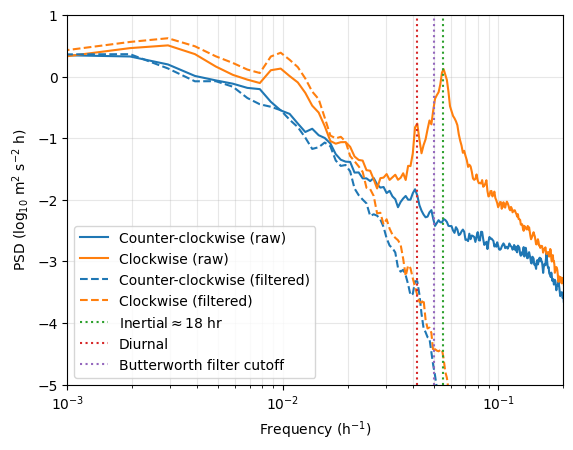

In [23]:
plt.figure()

f_ccw_h = f_ccw * 3600
f_cw_h  = f_cw  * 3600

Sccw_h = Sccw * 3600
Scw_h  = Scw  * 3600
Sccw_fitered_h = Sccw_fitered * 3600
Scw_fitered_h  = Scw_fitered  * 3600

plt.semilogx(f_ccw_h, np.log10(Sccw_h), label="Counter-clockwise (raw)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_h), label="Clockwise (raw)", color="C1")
plt.semilogx(f_ccw_h, np.log10(Sccw_fitered_h), "--", label="Counter-clockwise (filtered)", color="C0")
plt.semilogx(f_cw_h,  np.log10(Scw_fitered_h), "--", label="Clockwise (filtered)", color="C1")

plt.axvline(1/18, color="C2", linestyle=":", label="Inertial$\\approx 18$ hr")
plt.axvline(1/24, color="C3", linestyle=":", label="Diurnal")
plt.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth filter cutoff")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(1e-3, 2e-1)
plt.ylim(-5, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

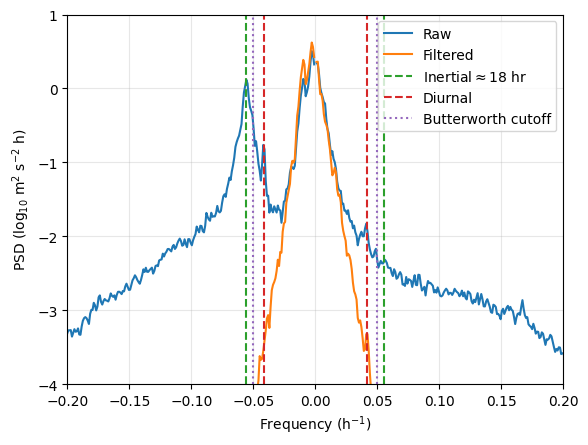

In [24]:
fig, ax = plt.subplots()

ax.plot(-f_cw_h, np.log10(Scw_h), color="C0", label="Raw")
ax.plot(f_ccw_h, np.log10(Sccw_h), color="C0")
ax.plot(-f_cw_h, np.log10(Scw_fitered_h), color="C1", label="Filtered")
ax.plot(f_ccw_h, np.log10(Sccw_fitered_h), color="C1",)

ax.axvline(-1/18, color="C2", linestyle="--", label="Inertial$\\approx 18$ hr")
ax.axvline(1/18, color="C2", linestyle="--")
ax.axvline(-1/24, color="C3", linestyle="--", label="Diurnal")
ax.axvline(1/24, color="C3", linestyle="--")
ax.axvline(1/cutoff, color="C4", linestyle=":", label="Butterworth cutoff")
ax.axvline(-1/cutoff, color="C4", linestyle=":")

plt.xlabel(r"Frequency (h$^{-1}$)")
plt.ylabel(r"PSD (log$_{10}$ m$^2$ s$^{-2}$ h)")

plt.xlim(-2e-1, 2e-1)
plt.ylim(-4, 1)

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

In [25]:
drifter_ds.to_zarr("data/drifters_drogue15m_CalVal.zarr", compute=True, mode="w")

/Users/bertrava/miniforge3/envs/swot-cyclogeo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
